# Week 10 (Mon) - Model Validation: Cross-Validation and Model Selection

**Chapter 11 -- Model Validation**

**Contents:**

- [Part 1 -- Why We Need Cross-Validation (Sec. 11.1)](#Part-1----Why-We-Need-Cross-Validation-(Sec.-11.1))
- [Part 2 -- Training / Validation / Testing Splits (Sec. 11.1)](#Part-2----Training-/-Validation-/-Testing-Splits-(Sec.-11.1))
- [Part 3 -- k-Fold Cross-Validation (Sec. 11.1)](#Part-3----k-Fold-Cross-Validation-(Sec.-11.1))
- [Part 4 -- Leave-One-Out Cross-Validation (Sec. 11.1)](#Part-4----Leave-One-Out-Cross-Validation-(Sec.-11.1))
- [Part 5 -- Model Selection with Cross-Validation (Sec. 11.2)](#Part-5----Model-Selection-with-Cross-Validation-(Sec.-11.2))
- [Part 6 -- Comparing Models and Examining Parameters (Sec. 11.2)](#Part-6----Comparing-Models-and-Examining-Parameters-(Sec.-11.2))
- [Wrap-Up: Putting It All Together](#Wrap-Up:-Putting-It-All-Together)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_validate,
                                     cross_val_score, KFold, StratifiedKFold,
                                     LeaveOneOut)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'none',   # adapt to light/dark notebook background
    'axes.facecolor': 'none',     # keep axes readable across themes
    'grid.alpha': 0.3
})

print('All libraries loaded.')
print('scikit-learn version:', sklearn.__version__)

All libraries loaded.
scikit-learn version: 1.8.0


## Quick Recap

Last week we explored **ensemble methods** (bagging, random forests, and boosting) which combine many weak learners into a strong model. We saw that ensembles are powerful, but a key question remains:

**How do we know our model is actually good?**

So far, we have been using a single `train_test_split` to evaluate our models. But is one split enough? What if we got lucky (or unlucky) with the split? Today we tackle this head-on with **cross-validation** and **model selection**.

---
## Part 1 -- Why We Need Cross-Validation (Sec. 11.1)

### Key Terminology

Before we dive in, let us define three critical stages in a machine learning workflow:

| Stage | Purpose | What happens |
|---|---|---|
| **Model Training** | Estimate model parameters | Fit weights, tree splits, etc. on training data |
| **Model Validation** | Tune and evaluate | Adjust hyperparameters (`k`, `max_depth`, etc.) using held-out data |
| **Model Testing** | Final performance check | Evaluate the final model on data it has never seen |

**Cross-validation** uses different subsets of the data for training and testing. By reserving a subset for evaluation, we avoid the **resubstitution bias** that comes from testing on training data so **the model never sees the test data during training**.

### The Problem with a Single Split

When we train on 100% of the data, we get the best possible parameter estimates, but we have **no data left** to evaluate model quality or compare hyperparameter settings.

When we do a single train/test split, the accuracy we get depends on **which rows** land in the training set and which land in the test set. A different random seed gives a different split and a different accuracy.

Let us see this in action.

In [20]:
# --- Load Palmer Penguins dataset ---
penguins = sns.load_dataset('penguins').dropna()

# Separate features and target
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = LabelEncoder().fit_transform(penguins['species'])  # 0=Adelie, 1=Chinstrap, 2=Gentoo
y = pd.Series(y, name='species', index=X.index)
species_names = ['Adelie', 'Chinstrap', 'Gentoo']


print(f'Penguins dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Features: {list(X.columns)}')
print(f'\n\nClasses: {species_names}  (3-class classification)')
for i, name in enumerate(species_names):
    print(f'   {i} ({name}): {(y == i).sum()}')
print(f' \n\nClass distribution (normalized):\n{y.value_counts(normalize=True)}')

Penguins dataset: 333 samples, 4 features
Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


Classes: ['Adelie', 'Chinstrap', 'Gentoo']  (3-class classification)
   0 (Adelie): 146
   1 (Chinstrap): 68
   2 (Gentoo): 119
 

Class distribution (normalized):
species
0    0.438438
2    0.357357
1    0.204204
Name: proportion, dtype: float64


KNN (k=5) accuracy across 50 different random splits:
  Min:  0.950
  Max:  1.000
  Mean: 0.985
  Std:  0.012
  Range: 0.050


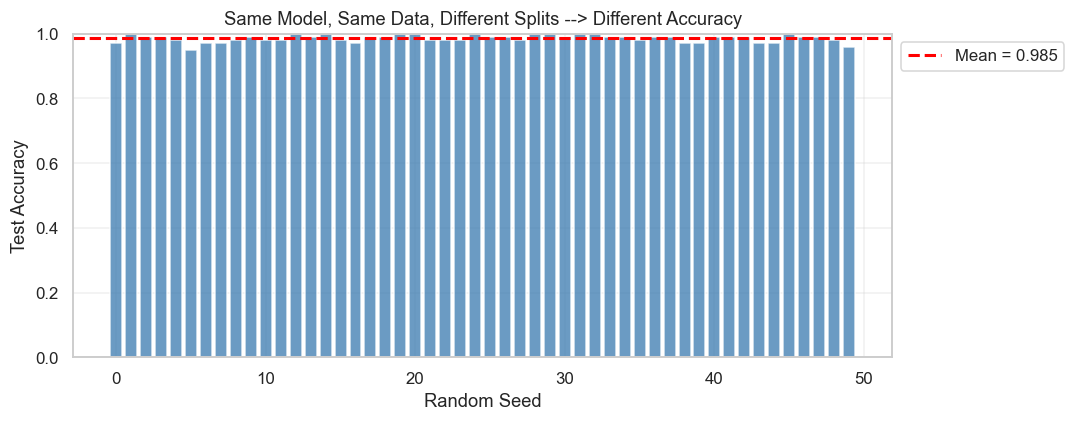

In [21]:
# --- Show how accuracy varies with different random splits ---
accuracies = []
seeds = range(50)
k = 5   # kNN parameter

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=seed)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    accuracies.append(knn.score(X_test_sc, y_test))

print(f'KNN (k={k}) accuracy across 50 different random splits:')
print(f'  Min:  {min(accuracies):.3f}')
print(f'  Max:  {max(accuracies):.3f}')
print(f'  Mean: {np.mean(accuracies):.3f}')
print(f'  Std:  {np.std(accuracies):.3f}')
print(f'  Range: {max(accuracies) - min(accuracies):.3f}')

# --- Plot the variability ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(seeds, accuracies, color='steelblue', edgecolor='white', alpha=0.8)
ax.axhline(np.mean(accuracies), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(accuracies):.3f}')
ax.set_xlabel('Random Seed')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.0, 1.0)
ax.set_title('Same Model, Same Data, Different Splits --> Different Accuracy')
ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
plt.tight_layout()
plt.show()

The bar chart above makes the point vividly: the **same KNN model** on the **same data** produces a wide range of test accuracies just by changing which rows go into training vs. testing. Reporting any single number would be misleading.


This is one of the reaons why we need cross-validation: to get a **stable, reliable estimate** of model performance.

> **[Q]** If you train a model on 100% of the data and report its training accuracy, why is that number unreliable as an estimate of future performance?

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Note: The General ML Formulation -- Parameters, Hyperparameters, and Losses**

Every supervised ML model we have seen (linear regression, logistic regression, KNN, decision trees, random forests) fits within one general framework.

**Goal.** Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, find a function $\hat{f}$ that maps inputs $\mathbf{x}$ to outputs $y$.

**Training: minimize a loss function over parameters.**
During training we search for the best **parameters** $\boldsymbol{\theta}$ (also called model parameters or weights) by minimizing a **loss function** $\mathcal{L}$ on the training data:

$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \; \frac{1}{n} \sum_{i=1}^{n} \mathcal{L}\!\bigl(y_i,\; f(\mathbf{x}_i;\, \boldsymbol{\theta})\bigr)$$

| | **Parameters** ($\boldsymbol{\theta}$) | **Hyperparameters** ($\lambda$) |
|---|---|---|
| **Symbol** | $w_0, w_1, \ldots$ | $k, C, \texttt{max\_depth}, \texttt{n\_estimators}$ |
| **Examples** | Regression weights, tree split thresholds, SVM support vectors | KNN neighbors, regularization strength, tree depth, number of trees |
| **Learned from data?** | Yes (optimized during training) | No (set **before** training by the practitioner) |

**Common loss functions used during training:**

| | Description |
|---|---|
| **Regression loss** | Mean Squared Error (MSE): $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ |
| **Classification loss** | Cross-Entropy (Log Loss): $-\frac{1}{n}\sum\bigl[y_i \ln \hat{p}_i + (1-y_i)\ln(1-\hat{p}_i)\bigr]$ |

**Evaluation: measure performance with a different metric on held-out data.**
After training, we evaluate on data the model has **never seen** using metrics that may differ from the training loss:

| | Metric | Why different from the loss? |
|---|---|---|
| **Regression** | $R^2$, MAE, RMSE | More interpretable than raw MSE |
| **Classification** | Accuracy, Precision, Recall, F1 | Directly meaningful for decision-making |

**Key insight:** The loss function is the optimizer's compass during training. The evaluation metric is the practitioner's compass for judging the final model. They need not be the same function, and they are computed on **different data** (training vs. held-out).

</div>

---
## Part 2 -- Training / Validation / Testing Splits (Sec. 11.1)

### The Three-Way Split

In practice we often need **three** subsets, not just two:

1. **Training set**: used to fit the model (estimate parameters).
2. **Validation set**: used to tune hyperparameters and compare candidate models.
3. **Testing set**: used **once** at the very end to report final performance.

The typical workflow is a two-step split:

```
Complete Dataset
    |----> Training Set (e.g., 70-80%)
    |         |----> Training subset (fit the model)
    |         |----> Validation subset (tune hyperparameters)
    |----> Testing Set (e.g., 20-30%)  [DO NOT TOUCH until the end]
```

**Important:** The testing set is a "locked vault." You only open it once. If you repeatedly evaluate on the test set and tweak your model, you are effectively training on the test set and your reported metric is no longer trustworthy.

### Trade-offs in Split Proportions

| More training data | More testing data |
|---|---|
| Better parameter estimates | More reliable performance estimate |
| Less data to evaluate on | Less data to learn from |
| More computationally expensive | Faster training |

Common splits: **70/15/15**, **80/10/10**, or **80/20** (no separate validation set for simple models like linear regression that have no hyperparameters).

### `train_test_split()` in scikit-learn

scikit-learn's `train_test_split()` divides input features `X` and target `y` into a train/test split. It returns four objects in this order: `X_train`, `X_test`, `y_train`, `y_test`.

| Parameter | Default | Description |
|---|---|---|
| `test_size` | None | Proportion (float 0.0--1.0) or absolute count (int) for the test set |
| `train_size` | None | Proportion or absolute count for the training set |
| `random_state` | None | Seed for reproducibility |
| `stratify` | None | Pass the target `y` to preserve class proportions |

To create a **three-way split**, call `train_test_split()` twice.

In [22]:
# --- Step 1: Split into Training (80%) and Testing (20%) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# --- Step 2: Split Training into Training (80% of 80% = 64%) and Validation (20% of 80% = 16%) ---
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full)

print(f'Original dataset:  {X.shape[0]} samples')
print(f'Training set:      {X_train.shape[0]} samples  ({X_train.shape[0]/X.shape[0]:.0%})')
print(f'Validation set:    {X_val.shape[0]} samples  ({X_val.shape[0]/X.shape[0]:.0%})')
print(f'Testing set:       {X_test.shape[0]} samples  ({X_test.shape[0]/X.shape[0]:.0%})')

Original dataset:  333 samples
Training set:      212 samples  (64%)
Validation set:    54 samples  (16%)
Testing set:       67 samples  (20%)


### Stratified Splits

When a class is **rare** or the dataset is **imbalanced**, pure random sampling can create splits where some classes are underrepresented (or even missing) in the validation or test sets.

**Stratified splits** ensure that each subset has the **same proportion of each class** as the full dataset.

- In **classification**: each class appears in the same ratio across train/val/test.
- In **regression**: there are no discrete classes, so stratification bins the continuous target $y$ into quantiles and ensures each bin is represented proportionally in every subset. This prevents splits where, e.g., all high-value homes end up in training and the test set only contains low-value homes.

> **Note:** scikit-learn's `train_test_split(stratify=y)` requires discrete labels. For regression, you can create bins first: `stratify=pd.qcut(y, q=5, labels=False)` to stratify on target quintiles.

Use `stratify=y` in `train_test_split()` to enable stratification.

Imbalanced class distribution:
  Adelie: 146  (83.0%)
  Chinstrap: 20  (11.4%)
  Gentoo: 10  (5.7%)


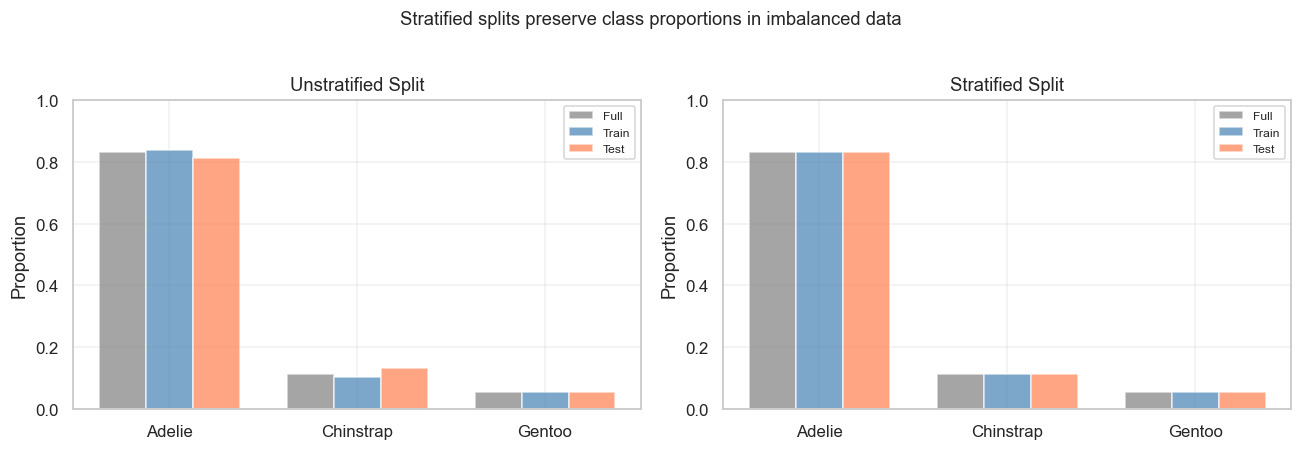

In [23]:
# --- Create an imbalanced version of the Penguins dataset ---
# Keep all Adelie (majority), subsample Chinstrap and Gentoo
np.random.seed(42)
idx_0 = y[y == 0].index                                    # all Adelie (~146)
idx_1 = y[y == 1].sample(n=20, random_state=42).index      # 20 Chinstrap
idx_2 = y[y == 2].sample(n=10, random_state=42).index      # 10 Gentoo
imb_idx = idx_0.append(idx_1).append(idx_2)
X_imb, y_imb = X.loc[imb_idx], y.loc[imb_idx]

print('Imbalanced class distribution:')
for i, name in enumerate(species_names):
    cnt = (y_imb == i).sum()
    print(f'  {name}: {cnt}  ({cnt/len(y_imb):.1%})')

# --- Compare stratified vs. unstratified splits ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unstratified
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=7)  # no stratify

# Stratified
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=7, stratify=y_imb)

# Plot class proportions
for ax, title, y_tr, y_te in [
    (axes[0], 'Unstratified Split', y_tr_u, y_te_u),
    (axes[1], 'Stratified Split', y_tr_s, y_te_s)]:
    
    full_props = y_imb.value_counts(normalize=True).sort_index().values
    train_props = y_tr.value_counts(normalize=True).sort_index().values
    test_props = y_te.value_counts(normalize=True).sort_index().values
    
    x_pos = np.arange(len(full_props))
    width = 0.25
    ax.bar(x_pos - width, full_props, width, label='Full', color='gray', alpha=0.7)
    ax.bar(x_pos, train_props, width, label='Train', color='steelblue', alpha=0.7)
    ax.bar(x_pos + width, test_props, width, label='Test', color='coral', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(species_names)
    ax.set_ylabel('Proportion')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.0)

plt.suptitle('Stratified splits preserve class proportions in imbalanced data',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# --- Show that unstratified splits can lose entire classes ---
print('Test-set class counts across 20 random unstratified splits:')
print(f'{"Seed":>4s}   {"Adelie":>6s}  {"Chinstrap":>9s}  {"Gentoo":>6s}   Note')
print('-' * 55)

missing_count = 0
for seed in range(20):
    _, _, _, y_te = train_test_split(
        X_imb, y_imb, test_size=0.30, random_state=seed)
    counts = y_te.value_counts().reindex([0, 1, 2], fill_value=0)
    flag = ''
    if (counts == 0).any():
        missing_names = [species_names[i] for i in counts[counts == 0].index]
        flag = f'<-- {", ".join(missing_names)} MISSING!'
        missing_count += 1
    print(f'{seed:4d}   {counts[0]:6d}  {counts[1]:9d}  {counts[2]:6d}   {flag}')

print(f'\nSplits where at least one class is missing: {missing_count} / 20')
print('With stratify=y, every split is guaranteed to include all classes.')

Test-set class counts across 20 random unstratified splits:
Seed   Adelie  Chinstrap  Gentoo   Note
-------------------------------------------------------
   0       45          6       2   
   1       45          7       1   
   2       44          9       0   <-- Gentoo MISSING!
   3       46          6       1   
   4       41          9       3   
   5       49          4       0   <-- Gentoo MISSING!
   6       42          9       2   
   7       43          7       3   
   8       43          7       3   
   9       40          9       4   
  10       47          3       3   
  11       48          2       3   
  12       41          8       4   
  13       44          5       4   
  14       42          6       5   
  15       44          6       3   
  16       40         10       3   
  17       43          5       5   
  18       44          6       3   
  19       42          6       5   

Splits where at least one class is missing: 2 / 20
With stratify=y, every split is gu

---
## Part 3 -- k-Fold Cross-Validation (Sec. 11.1)

### The Idea

A single train/val/test split still depends on **one** random partition. **k-Fold cross-validation** goes further:

1. Split the training data into $k$ equal-sized, non-overlapping subsets called **folds**.
2. For each fold $i = 1, 2, \ldots, k$:
   - Use fold $i$ as the **validation** set.
   - Use the remaining $k-1$ folds as the **training** set.
   - Train the model and record the validation score.
3. Report the **mean** and **standard deviation** of the $k$ scores.

![Fig from Activity 11.8.1, ZyBook](media/kfold.png)

Every instance is used for validation **exactly once** and for training **exactly $k-1$ times**.

**How many folds?** Typical values are $k = 5$ or $k = 10$. More folds means:
- Each training set is larger (better parameter estimates).
- But more iterations = more computation.
- Less bias, but potentially more variance between folds.

### `cross_validate()` in scikit-learn

`cross_validate(estimator, X, y)` performs k-fold cross-validation and returns a dictionary of results.

| Parameter | Default | Description |
|---|---|---|
| `estimator` | required | A scikit-learn model (e.g., `KNeighborsClassifier()`) |
| `scoring` | None | Performance metric(s). Default: accuracy (classification) or $R^2$ (regression) |
| `cv` | 5 | Number of folds, or a cross-validation splitter object like `KFold()` |
| `return_train_score` | False | Also return scores on each training fold |
| `return_estimator` | False | Return the fitted model from each fold |

The returned dictionary contains:
- `test_score`: validation score for each fold
- `train_score`: training score for each fold (if requested)
- `fit_time`: time to fit the model on each fold
- `estimator`: fitted model objects (if requested)

In [24]:
# --- 5-Fold Cross-Validation with KNN ---
kn = 3  # kNN parameter
kf = 5  # k-folds for cross-validation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=kn)

cv_results = cross_validate(knn, X_scaled, y, cv=kf,
                            return_train_score=True)

print(f'5-Fold Cross-Validation Results (KNN, k={kn}):')
print(f'  Training scores:   {cv_results["train_score"]}')
print(f'  Validation scores: {cv_results["test_score"]}')
print(f'  {"-"*40}')
print(f'  Mean validation accuracy: {cv_results["test_score"].mean():.3f}')
print(f'  Std validation accuracy:  {cv_results["test_score"].std():.3f}')

5-Fold Cross-Validation Results (KNN, k=3):
  Training scores:   [0.9962406  0.9924812  0.9887218  0.98876404 0.99625468]
  Validation scores: [0.98507463 0.98507463 0.97014925 1.         1.        ]
  ----------------------------------------
  Mean validation accuracy: 0.988
  Std validation accuracy:  0.011


### 10-Fold Cross-Validation

Let us try 10 folds and see how the results compare.

In [25]:
# --- 10-Fold Cross-Validation ---
cv_results_10 = cross_validate(knn, X_scaled, y, cv=10,
                               return_train_score=True)

print('10-Fold Cross-Validation Results (KNN, k=5):')
print(f'  Validation scores: {np.round(cv_results_10["test_score"], 3)}')
print(f'  Mean validation accuracy: {cv_results_10["test_score"].mean():.3f}')
print(f'  Std validation accuracy:  {cv_results_10["test_score"].std():.3f}')
print()
print('Comparison:')
print(f'  5-fold mean: {cv_results["test_score"].mean():.3f} +/- {cv_results["test_score"].std():.3f}')
print(f' 10-fold mean: {cv_results_10["test_score"].mean():.3f} +/- {cv_results_10["test_score"].std():.3f}')

10-Fold Cross-Validation Results (KNN, k=5):
  Validation scores: [1.    0.971 0.971 1.    0.939 1.    1.    1.    1.    0.97 ]
  Mean validation accuracy: 0.985
  Std validation accuracy:  0.020

Comparison:
  5-fold mean: 0.988 +/- 0.011
 10-fold mean: 0.985 +/- 0.020


> **[Q]** In a 1000 instances dataset we use 10% for testing and use 10-fold CV on a dataset, how many instances are in each fold? How many instances does each model train on?(The train/val/test split is 80%/10%/10%)

### Using `KFold()` for Control

When comparing multiple models, we need to ensure they all use the **same folds**. The `KFold()` object lets us define folds once and reuse them.

- `KFold(n_splits=k, shuffle=True, random_state=42)`: creates $k$ folds with random shuffling.
- `StratifiedKFold(n_splits=k, shuffle=True, random_state=42)`: same but preserves class proportions in each fold.

Pass the fold object as the `cv` parameter in `cross_validate()`.

In [26]:
# --- Define folds once, reuse for multiple models ---
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Show which indices go into each fold
for fold_num, (train_idx, val_idx) in enumerate(kfolds.split(X_scaled, y), 1):
    print(f'Fold {fold_num}: Train={len(train_idx)} samples, '
          f'Val={len(val_idx)} samples, '
          f'Val indices (first 5): {val_idx[:5]}')

Fold 1: Train=266 samples, Val=67 samples, Val indices (first 5): [ 2  3  6  9 10]
Fold 2: Train=266 samples, Val=67 samples, Val indices (first 5): [ 0  4 15 18 19]
Fold 3: Train=266 samples, Val=67 samples, Val indices (first 5): [ 7  8 13 16 23]
Fold 4: Train=267 samples, Val=66 samples, Val indices (first 5): [ 1 11 20 25 27]
Fold 5: Train=267 samples, Val=66 samples, Val indices (first 5): [ 5 12 14 17 21]


---
## Part 4 -- Leave-One-Out Cross-Validation (Sec. 11.1)

### The Extreme Case: $k = n$

**Leave-One-Out Cross-Validation (LOOCV)** is k-fold CV taken to the extreme: each fold contains exactly **one** instance.

- Train on $n - 1$ instances, validate on 1 instance.
- Repeat $n$ times (once for every instance).
- The CV score is the average across all $n$ iterations.

**When is LOOCV useful?**
- Very small datasets where every data point matters.
- Identifying **outliers**, i.e. instances with unusually high prediction error.

**Drawbacks:**
- Very computationally expensive for large datasets ($n$ models to fit!).
- Individual validation scores are either 0 or 1 (for classification) or a single squared error (for regression), so they are very noisy.
- High variance because training sets overlap heavily ($n-1$ out of $n$ instances are shared between any two iterations).

In [27]:
# --- LOOCV Demo ---
loo = LeaveOneOut()

print(f'Dataset size: {X_scaled.shape[0]} samples')
print(f'LOOCV will fit {loo.get_n_splits(X_scaled)} models (one per sample)')
print()

loo_results = cross_validate(knn, X_scaled, y, cv=loo)

print(f'LOOCV Results (KNN, k={knn.n_neighbors}):')
print(f'  Mean accuracy: {loo_results["test_score"].mean():.3f}')
print('  Each score is 0 or 1 (single instance correct/incorrect)')
print(f'  Number correct: {loo_results["test_score"].sum():.0f} / {len(loo_results["test_score"])}')

Dataset size: 333 samples
LOOCV will fit 333 models (one per sample)

LOOCV Results (KNN, k=3):
  Mean accuracy: 0.988
  Each score is 0 or 1 (single instance correct/incorrect)
  Number correct: 329 / 333


### Using LOOCV to Find Outliers

One powerful use of LOOCV is to find **influential observations** instances that the model consistently gets wrong. If the model predicts a sample incorrectly when that sample is the only one held out, it may be an outlier or a mislabeled point.

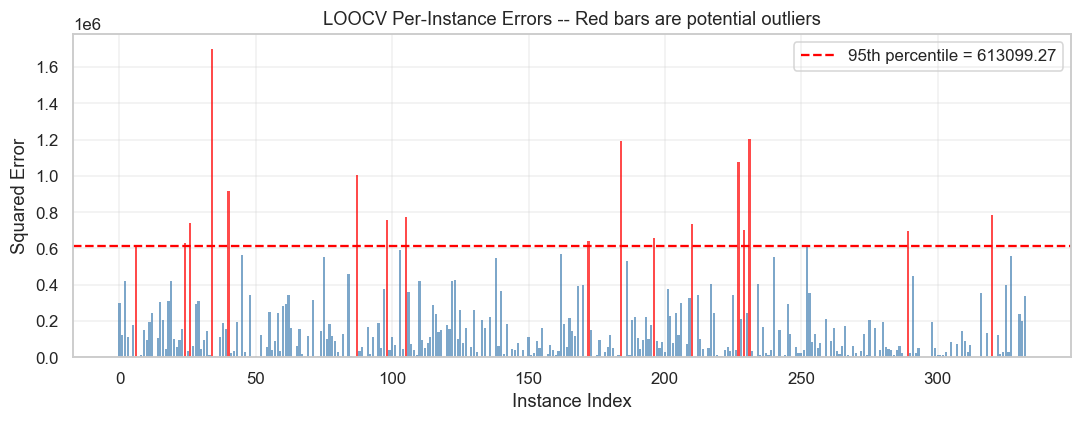

Instances with error above 95th percentile: 17


In [28]:
# --- LOOCV for outlier detection (regression example) ---
# Use two features to predict body mass
X_reg = X[['flipper_length_mm', 'bill_length_mm']].values
y_reg = X['body_mass_g'].values

scaler_reg = StandardScaler()
X_reg_sc = scaler_reg.fit_transform(X_reg)

lr = LinearRegression()
loo_reg = cross_validate(lr, X_reg_sc, y_reg, cv=LeaveOneOut(),
                         scoring='neg_mean_squared_error')

# Convert negative MSE to positive
loo_mse = -loo_reg['test_score']

# --- Plot the per-instance MSE ---
PRCT = 0.95  # percentile threshold for outlier detection
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red' if mse > np.percentile(loo_mse, PRCT*100) else 'steelblue'
          for mse in loo_mse]
ax.bar(range(len(loo_mse)), loo_mse, color=colors, alpha=0.7, edgecolor='none')
ax.axhline(np.percentile(loo_mse, PRCT*100), color='red', linestyle='--',
           label=f'{int(PRCT*100)}th percentile = {np.percentile(loo_mse, PRCT*100):.2f}')
ax.set_xlabel('Instance Index')
ax.set_ylabel('Squared Error')
ax.set_title('LOOCV Per-Instance Errors -- Red bars are potential outliers')
ax.legend()
plt.tight_layout()
plt.show()

n_outliers = sum(1 for mse in loo_mse if mse > np.percentile(loo_mse, PRCT*100))
print(f'Instances with error above {int(PRCT*100)}th percentile: {n_outliers}')

> **[Q]** Why is LOOCV more computationally expensive than 10-fold CV? For a dataset of 10,000 instances, how many models does each approach fit?

---
## Part 5 -- Model Selection with Cross-Validation (Sec. 11.2)

### What is Model Selection?

**Model selection** is the process of choosing the best model (or the best hyperparameters for a given model) from a set of candidates. Cross-validation is the standard tool for this.

Model selection operates at two levels:

1. **Hyperparameter tuning** (same algorithm, different settings):
   - KNN with $k=3$ vs. $k=5$ vs. $k=7$
   - Random Forest with 100 trees vs. 500 trees

2. **Algorithm comparison** (different model families):
   - Best KNN vs. best Decision Tree vs. best Logistic Regression

In practice, you do **both**: first tune each algorithm's hyperparameters via CV, then compare the best-tuned version of each algorithm against each other.
### Steps for Model Selection with Cross-Validation

1. **Define a shared set of cross-validation folds** (same folds for all models).
2. **Train and validate** every candidate model on every fold.
3. **Compare** performance metrics across folds using descriptive statistics or plots.

**Critical rule:** The same folds must be used for all models so the comparison is fair. If Model A uses one random partition and Model B uses a different one, the performance difference might just reflect the data split, not the models.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Note**: model selection is done on train/val data. The workflow is:
1. Hold out a test set (the vault).
2. On the remaining data, use CV to tune and compare models. All decisions are based on validation scores.
3. Pick the winner, retrain on all training data, evaluate once on the test set.

Note that if you use test accuracy to choose between models, you are effectively fitting to the test set, and the reported test accuracy is no longer an unbiased estimate of generalization performance.



### `cross_validate()` in scikit-learn

`cross_validate(estimator, X, y)` performs k-fold cross-validation and returns a dictionary of results.

| Parameter | Default | Description |
|---|---|---|
| `estimator` | required | A scikit-learn model (e.g., `KNeighborsClassifier()`) |
| `scoring` | None | Performance metric(s). Default: accuracy (classification) or $R^2$ (regression) |
| `cv` | 5 | Number of folds, or a cross-validation splitter object like `KFold()` |
| `return_train_score` | False | Also return scores on each training fold |
| `return_estimator` | False | Return the fitted model from each fold |

The returned dictionary contains:
- `test_score`: validation score for each fold
- `train_score`: training score for each fold (if requested)
- `fit_time`: time to fit the model on each fold
- `estimator`: fitted model objects (if requested)

In [29]:
# --- Model Selection: Compare 4 models using the same folds ---
kfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    cv = cross_validate(model, X_scaled, y, cv=kfolds,
                        return_train_score=True)
    results[name] = cv
    print(f'{name:25s}  '
          f'Val acc: {cv["test_score"].mean()*100:.1f}% +/- {cv["test_score"].std()*100:.1f}%  '
          f'Train acc: {cv["train_score"].mean()*100:.1f}%')

KNN (k=3)                  Val acc: 98.5% +/- 1.5%  Train acc: 99.4%
KNN (k=7)                  Val acc: 98.5% +/- 1.5%  Train acc: 99.1%
Logistic Regression        Val acc: 98.8% +/- 1.5%  Train acc: 99.1%
Decision Tree              Val acc: 96.1% +/- 3.3%  Train acc: 100.0%


### Hyperparameter Tuning with CV

Let us use cross-validation to find the best `k` for KNN.

Best k = 9 with mean CV accuracy = 98.8%


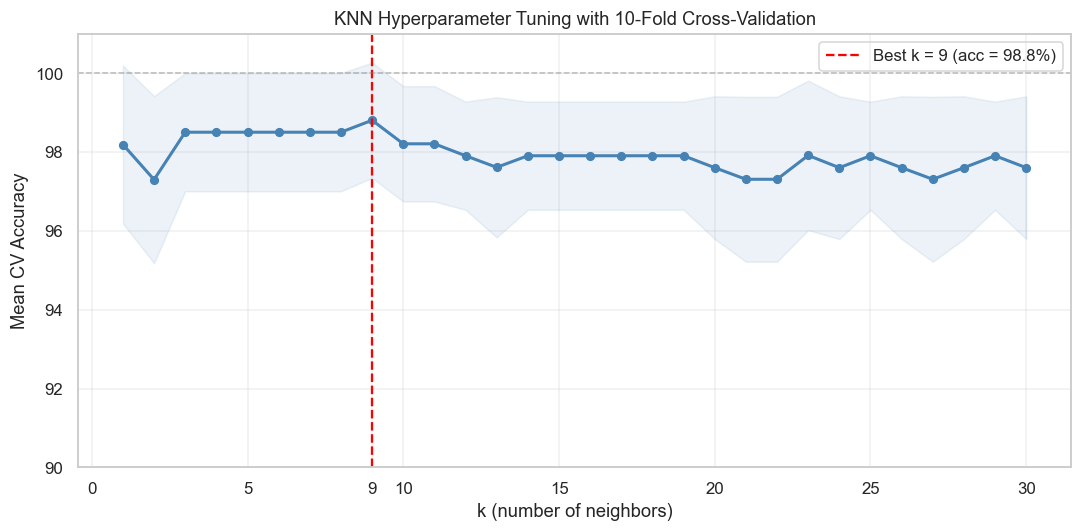

In [30]:
# --- Hyperparameter tuning: find the best k for KNN ---
k_values = range(1, 31)
mean_scores = []
std_scores = []

kfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv = cross_validate(knn_k, X_scaled, y, cv=kfolds)
    mean_scores.append(cv['test_score'].mean())
    std_scores.append(cv['test_score'].std())

mean_scores = np.array(mean_scores)
std_scores = np.array(std_scores)
best_k = k_values[np.argmax(mean_scores)]

print(f'Best k = {best_k} with mean CV accuracy = {mean_scores.max()*100:.1f}%')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, mean_scores * 100, 'o-', color='steelblue', linewidth=2, markersize=5)
ax.fill_between(k_values,
                (mean_scores - std_scores) * 100,
                (mean_scores + std_scores) * 100,
                alpha=0.1, color='steelblue')
ax.axvline(best_k, color='red', linestyle='--',
           label=f'Best k = {best_k} (acc = {mean_scores.max()*100:.1f}%)')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('KNN Hyperparameter Tuning with 10-Fold Cross-Validation')
ax.legend()
ax.set_xticks(list(range(0, 31, 5)) + [best_k])
ax.set_ylim(90.0, 101.0)
ax.axhline(100.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

The shaded region shows $\pm 1$ standard deviation across the 10 folds. The model with the highest mean CV accuracy and reasonable stability is preferred.

Notice how small $k$ values (like $k=1$) tend to overfit (high training accuracy but lower and more variable validation accuracy), while very large $k$ values underfit (accuracy drops as the model becomes too simple).


<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Side note on the figure**:

Note, the band shows *mean +/- 1 std* a simple symmetric summary of spread. When mean accuracy is very high (say 97%) and the standard deviation is around 4%, the upper edge lands at 101%. This does not mean any fold actually scored above 100%. It just means the bell-curve-style summary extends past the natural boundary. Think of it like a confidence interval for height that dips below zero for very short populations: mathematically valid, but physically impossible. The band is there to show **how much the scores vary across folds** and this happens bcz we purely rely on statistics with symmetric assumption on both ways. It doesn't reflect the inherent laws of the problem.

</div>

> **[Q]** After using cross-validation to select the best hyperparameters, should you report the CV accuracy as your final result? Why or why not?

---
## Part 6 -- Comparing Models and Examining Parameters (Sec. 11.2)

### Comparing Models with Box Plots

When comparing multiple models, looking at the mean CV score alone can be misleading. We care about:

- **Central tendency** (mean, median) i.e. which model is best on average?
- **Variability** (std, IQR, range) i.e. which model is most consistent?

A model with slightly lower mean accuracy but much lower variance may be preferred as it is more **reliable** performance-wise.

Box plots give a compact visual summary of the fold-by-fold scores.

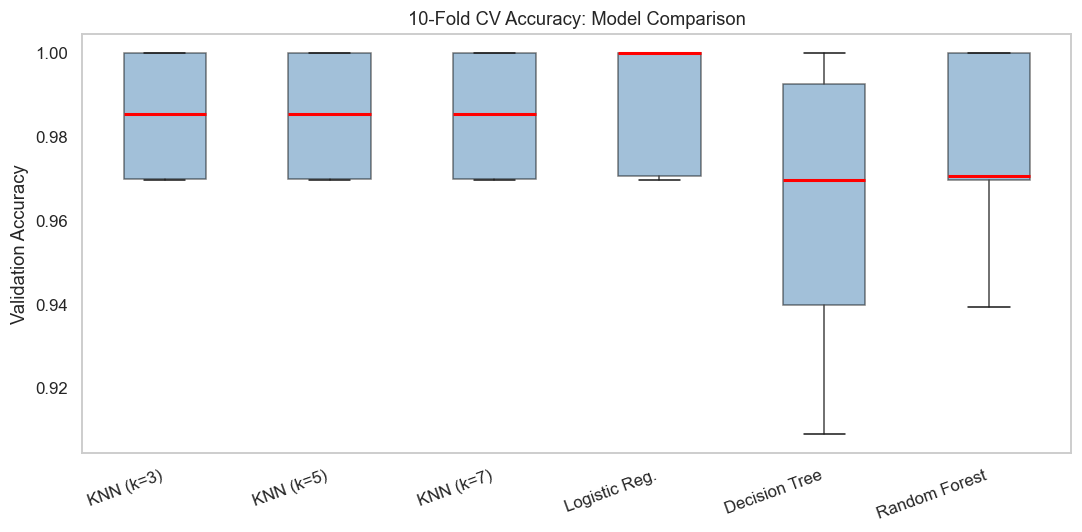


Summary Statistics:
                Mean  Median    Std    Min  Max    IQR
KNN (k=3)      0.985   0.985  0.016  0.970  1.0  0.030
KNN (k=5)      0.985   0.985  0.016  0.970  1.0  0.030
KNN (k=7)      0.985   0.985  0.016  0.970  1.0  0.030
Logistic Reg.  0.988   1.000  0.015  0.970  1.0  0.029
Decision Tree  0.961   0.970  0.035  0.909  1.0  0.053
Random Forest  0.976   0.971  0.024  0.939  1.0  0.030


In [31]:
# --- Expanded model comparison with box plots ---
kfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_expanded = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Logistic Reg.': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

all_scores = {}
for name, model in models_expanded.items():
    cv = cross_validate(model, X_scaled, y, cv=kfolds)
    all_scores[name] = cv['test_score']

# --- Box plot ---
fig, ax = plt.subplots(figsize=(10, 5))
score_data = pd.DataFrame(all_scores)
score_data.boxplot(ax=ax, grid=False, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.5),
                   medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Validation Accuracy')
ax.set_title('10-Fold CV Accuracy: Model Comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# --- Summary table ---
summary = pd.DataFrame({
    'Mean': score_data.mean(),
    'Median': score_data.median(),
    'Std': score_data.std(),
    'Min': score_data.min(),
    'Max': score_data.max(),
    'IQR': score_data.quantile(0.75) - score_data.quantile(0.25)
}).round(3)
print('\nSummary Statistics:')
print(summary)

> **[Q]** Looking at the box plot above, which model would you select and why? Consider both accuracy and consistency.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Why does Logistic Regression dominate here?**

The Palmer Penguins species are nearly **linearly separable** in the 4-feature space (bill length, bill depth, flipper length, body mass). Gentoo separates almost perfectly on body mass and flipper length alone; Adelie vs. Chinstrap is tighter but still clean. A linear decision boundary, which is exactly what Logistic Regression fits, is close to optimal for this geometry.

With 10-fold CV on ~333 samples, each validation fold has ~33 instances. A median of 1.000 just means at least half the folds classified all ~33 samples correctly, which is very plausible when classes barely overlap.

**Takeaway:** When the data is clean, low-dimensional, and nearly linearly separable, the simplest model that matches the data geometry often wins. Complexity does not help when a hyperplane already does the job. The next experiment shows what happens when the decision boundary is **not** linear.

</div>

### What if the data is NOT linearly separable?

The Penguins dataset is almost too clean for a fair comparison. Let us repeat the same experiment on a **harder** dataset, the scikit-learn `make_moons` dataset, where the true boundary is curved. Now a linear model should struggle, and a flexible model should shine.

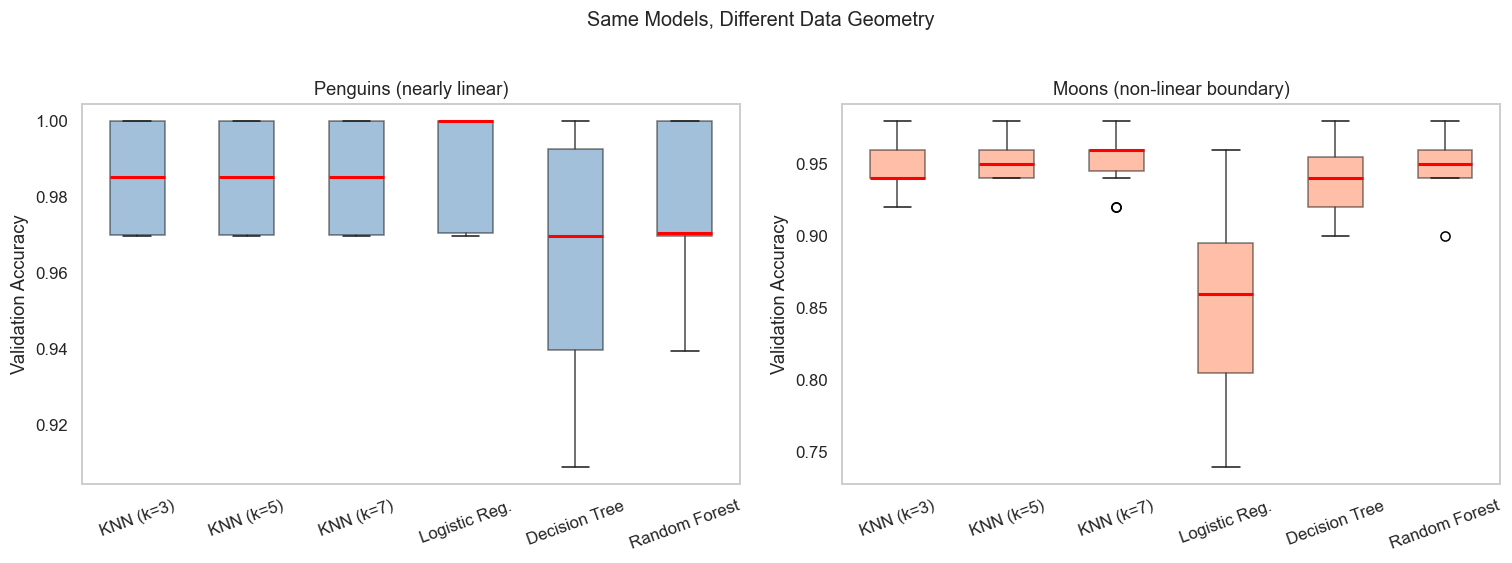

Moons dataset -- Summary:
                Mean    Std
KNN (k=3)      0.946  0.019
KNN (k=5)      0.952  0.014
KNN (k=7)      0.954  0.021
Logistic Reg.  0.850  0.065
Decision Tree  0.938  0.024
Random Forest  0.948  0.021

Best model on Moons: KNN (k=7) (0.954)
Best model on Penguins: Logistic Reg. (0.988)


In [32]:
from sklearn.datasets import make_moons

# --- Generate a non-linearly-separable dataset ---
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

kfolds_m = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_m = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Logistic Reg.': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

all_scores_m = {}
for name, model in models_m.items():
    cv = cross_validate(model, X_moons, y_moons, cv=kfolds_m)
    all_scores_m[name] = cv['test_score']

# --- Side-by-side box plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Penguins (from earlier)
score_data.boxplot(ax=axes[0], grid=False, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.5),
                   medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Penguins (nearly linear)')
axes[0].tick_params(axis='x', rotation=20)

# Moons
score_data_m = pd.DataFrame(all_scores_m)
score_data_m.boxplot(ax=axes[1], grid=False, patch_artist=True,
                     boxprops=dict(facecolor='coral', alpha=0.5),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Moons (non-linear boundary)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Same Models, Different Data Geometry', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
summary_m = pd.DataFrame({
    'Mean': score_data_m.mean(),
    'Std': score_data_m.std(),
}).round(3)
print('Moons dataset -- Summary:')
print(summary_m)
print(f'\nBest model on Moons: {summary_m["Mean"].idxmax()} '
      f'({summary_m["Mean"].max():.3f})')
print(f'Best model on Penguins: {score_data.mean().idxmax()} '
      f'({score_data.mean().max():.3f})')

On the Moons dataset, Logistic Regression drops significantly because the true boundary is a **curve**, not a line. Models that can capture non-linear boundaries (KNN, Decision Tree, and especially Random Forest) now take the lead.

**Lesson:** There is no universally best model. The right choice depends on the **geometry of the data**. This is exactly why we use cross-validation to compare, so the data tells us which model fits best rather than guessing.

### Examining Parameter Stability Across Folds

For interpretable models like Logistic Regression, cross-validation also lets us check if the **parameter estimates** (weights) are stable across folds.

- If weights are **consistent** across folds, the model is robust.
- If weights are **highly variable**, the model may be overfitting to particular training subsets.
- **Skewed** weight distributions may indicate that a few folds have unusual data.

In [33]:
# --- Examine Logistic Regression weights across folds ---
kfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_cv = cross_validate(
    LogisticRegression(max_iter=5000), X_scaled, y,
    cv=kfolds, return_estimator=True)

# Collect weights from each fold (for first class, one-vs-rest)
feature_names = list(X.columns)
weights_df = pd.DataFrame(
    [est.coef_[0] for est in lr_cv['estimator']],
    columns=feature_names
)

# --- Show first few feature weights ---
print('Logistic Regression weights (class 0 vs rest) across 10 folds:')
print(weights_df.iloc[:, :5].round(3).to_string())
print()
print('Standard deviation of weights across folds:')
print(weights_df.std().round(3).to_string())

Logistic Regression weights (class 0 vs rest) across 10 folds:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0          -2.669          1.431             -0.476        0.328
1          -2.621          1.477             -0.632        0.423
2          -2.695          1.487             -0.610        0.353
3          -2.637          1.446             -0.483        0.359
4          -2.662          1.492             -0.456        0.352
5          -2.609          1.555             -0.474        0.370
6          -2.632          1.498             -0.429        0.377
7          -2.671          1.526             -0.394        0.292
8          -2.587          1.460             -0.427        0.357
9          -2.624          1.379             -0.498        0.346

Standard deviation of weights across folds:
bill_length_mm       0.033
bill_depth_mm        0.050
flipper_length_mm    0.077
body_mass_g          0.033


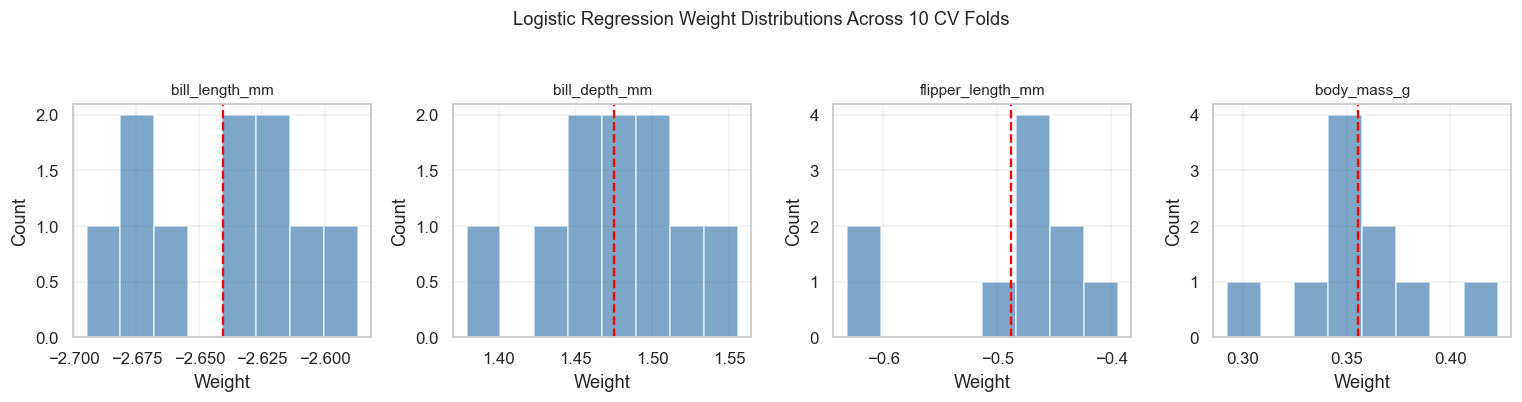

In [34]:
# --- Visualize weight distributions for selected features ---
# Pick the 4 features with highest mean absolute weight
top_features = weights_df.abs().mean().nlargest(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, feat in zip(axes, top_features):
    ax.hist(weights_df[feat], bins=8, color='steelblue',
            edgecolor='white', alpha=0.7)
    ax.axvline(weights_df[feat].mean(), color='red', linestyle='--',
               linewidth=1.5)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Weight')
    ax.set_ylabel('Count')

plt.suptitle('Logistic Regression Weight Distributions Across 10 CV Folds',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

The histograms above show how the weight for each feature varies across the 10 folds. Features with **tight** distributions are reliably important. Features with **spread-out** distributions may have unstable contributions, and their importance depends heavily on which samples are in the training set.

> **[Q]** If you see a feature whose weight flips sign across folds (sometimes positive, sometimes negative), what does that tell you about the feature?

### Complete Model Selection Workflow

Let us put everything together in a realistic workflow: **hold out a test set**, use **cross-validation** for model selection, then **evaluate the winner on the test set**.

In [35]:
# --- Complete Model Selection Workflow ---

# Step 1: Hold out 20% for final testing
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Step 2: Scale features (fit on training only!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_full)
X_test_sc = scaler.transform(X_test_final)

# Step 3: Define shared folds on TRAINING data
kfolds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 4: Compare candidates using CV on training data
candidates = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=13)': KNeighborsClassifier(n_neighbors=13),
    'Logistic Reg.': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

print('Step 4: Cross-Validation Model Comparison (on training data only)')
print('=' * 65)
best_name, best_score = None, 0
for name, model in candidates.items():
    cv = cross_validate(model, X_train_sc, y_train_full, cv=kfolds)
    mean_acc = cv['test_score'].mean()
    std_acc = cv['test_score'].std()
    print(f'  {name:20s}  CV acc: {mean_acc:.3f} +/- {std_acc:.3f}')
    if mean_acc > best_score:
        best_score = mean_acc
        best_name = name

print(f'\n  --> Best model by CV: {best_name} ({best_score:.3f})')

Step 4: Cross-Validation Model Comparison (on training data only)
  KNN (k=5)             CV acc: 0.985 +/- 0.018
  KNN (k=13)            CV acc: 0.977 +/- 0.031
  Logistic Reg.         CV acc: 0.981 +/- 0.026
  Random Forest         CV acc: 0.977 +/- 0.019

  --> Best model by CV: KNN (k=5) (0.985)


In [36]:
# Step 5: Train the best model on ALL training data and evaluate on test set
best_model = candidates[best_name]
best_model.fit(X_train_sc, y_train_full)
test_accuracy = best_model.score(X_test_sc, y_test_final)

print(f'Step 5: Final Evaluation on Test Set')
print(f'=' * 50)
print(f'  Model: {best_name}')
print(f'  CV accuracy (selection):  {best_score:.3f}')
print(f'  Test accuracy (final):    {test_accuracy:.3f}')
print()
print('This test accuracy is the number you would report.')

Step 5: Final Evaluation on Test Set
  Model: KNN (k=5)
  CV accuracy (selection):  0.985
  Test accuracy (final):    1.000

This test accuracy is the number you would report.


> **[Q]** Why do we fit the scaler on the training data only and then transform the test data with the same scaler, rather than scaling the entire dataset before splitting?